# Variant-level growth-rate benchmark across flu-like candidate simulations

Replicates figure 5's variant-specific `log(MAE)` growth-rate boxplot, pooled
across every flu-like candidate run (the same candidate set as figure 3). Each
box is the distribution of per-variant growth-rate error for one model in one
deme, over all converged variant-windows in all candidate simulations. The final
cell lists the highest-error variant-windows as candidate targets for the
per-case zoom-ins.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

# Styling and panel-letter placement come from antigentools.supplement_style
# so every supplement figure shares one definition; the values there were
# taken from this notebook, so nothing about how it renders changes.
from antigentools.supplement_style import apply_supplement_style, add_panel_letters

apply_supplement_style()

# --- parameters ---------------------------------------------------------
BATCH = '2026-07-04-reviewer-runs'
RESULTS_DIR = Path('..') / 'results' / BATCH          # per-run outputs live here
# Finalized figures live in the round1 review figures dir.
FIG_DIR = Path('..') / '..' / 'antigen-tex' / 'reviews' / 'round1' / 'figures'
CAND_PATH = Path('..') / 'data' / BATCH / 'antigen-outputs' / 'candidate_runs.csv'

MODEL_ORDER = ['FGA', 'GARW']
DEME_ORDER = ['north', 'tropics', 'south']
EPS = 1e-6               # floor before log, matching figure 5
N_ZOOM = 20             # how many top-error variant-windows to save for zoom-ins
MIN_POINTS = 3          # min trustworthy growth-rate points per variant; re-applies
                        # the pipeline's window-level MIN_SEGMENT_LENGTH at the
                        # variant level (the per-variant scorer omits it)

# Deme palette matches figure 5 (growth-rate errors).
deme_palette = {'tropics': '#3498db', 'north': '#e67e22', 'south': '#2ecc71'}
# Model colors for the ECDF panel (Okabe-Ito, colorblind-safe).
MODEL_COLORS = {'FGA': '#D55E00', 'GARW': '#0072B2'}

# Representative run highlighted (bold) in the ECDF panel. This becomes the run
# used for the main-text detailed analysis, replacing the stale flu-final build.
# Set REPRESENTATIVE_RUN to a (config, run) tuple once chosen; None picks a random
# candidate run (seeded, reproducible) as a placeholder so the overlay scaffolding
# is already in place.
REPRESENTATIVE_RUN = ('nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75', 14)
REPRESENTATIVE_SEED = 0

# log(MAE) threshold above which windows are treated as zoom-in-worthy (elevated
# error). Drawn as a red dashed line on the ECDF; where each curve crosses it
# shows how often such windows occur. Tweak to taste.
ZOOM_LOGMAE_THRESHOLD = -4.0

In [2]:
# --- candidate (config, run) filter ------------------------------------
# Identical to figure 3: restrict to the flu-like candidate keys.
cand = pd.read_csv(CAND_PATH)


def config_from_path(p):
    m = re.search(r'simulations/([^/]+)/run_', p)
    assert m is not None, f'cannot parse config from candidate path: {p!r}'
    return m.group(1)


cand['config'] = cand['path'].map(config_from_path)
cand_keys = set(zip(cand['config'], cand['run'].astype(int)))
print(f'{len(cand_keys)} flu-like candidate runs in {CAND_PATH.name}')

45 flu-like candidate runs in candidate_runs.csv


In [3]:
# --- load variant-level growth-rate errors from the per-run TSVs -------
# One row per (variant, pivot_date, model, deme) per run. The per-run
# variant_growth_rates.tsv files are git-tracked, so this is self-contained;
# config/run are recovered from each result dir name '<config>__run_<n>'.
def config_run_from_dir(dirname):
    m = re.match(r'(.+)__run_(\d+)$', dirname)
    assert m is not None, f'cannot parse config/run from result dir: {dirname!r}'
    return m.group(1), int(m.group(2))


frames = []
for tsv in sorted(RESULTS_DIR.glob('*__run_*/variant_growth_rates.tsv')):
    cfg, run = config_run_from_dir(tsv.parent.name)
    if (cfg, run) not in cand_keys:
        continue
    df = pd.read_csv(tsv, sep='\t')
    df['config'] = cfg
    df['run'] = run
    frames.append(df)

assert frames, f'no candidate variant_growth_rates.tsv found under {RESULTS_DIR}'
variants = pd.concat(frames, ignore_index=True)

n_present = variants.groupby(['config', 'run']).ngroups
print(f'{n_present}/{len(cand_keys)} candidate runs present, {len(variants)} variant-windows')

# Match figure 5: keep only converged fits.
variants = variants[variants['converged'] == True].copy()
variants = variants[variants['model'].isin(MODEL_ORDER)]
# Require a minimum number of trustworthy growth-rate points per variant. The
# per-variant scorer (calculate_variant_mae) applies point-level sequence /
# frequency / incidence filters but, unlike the window-level score, does NOT drop
# variants left with too few surviving points -- so single-point 'MAE's leak in.
# This re-applies the pipeline's window-level MIN_SEGMENT_LENGTH at the variant
# level, so both the boxplot and the zoom-in targets use trustworthy errors.
variants = variants[variants['n_points'] >= MIN_POINTS]
variants['log_mae'] = np.log(variants['mae'] + EPS)
print(f'{len(variants)} variant-windows retained (converged, n_points >= {MIN_POINTS})')

# CAVEAT (see antigen-forecasting issue #29): the `converged` filter drops far more
# FGA windows than GARW (FGA retains ~1/3 as many), so the boxplot/ECDF compare
# FGA's converged subset against GARW's -- a survivorship bias that flatters FGA.
# The near-identical FGA/GARW error distributions must be read with this in mind;
# why FGA converges less often is left to investigate (issue #29) and needs a note
# in the revised text.
print('  per-model retained:', variants.groupby('model').size().to_dict())

# Representative run to highlight (bold) in the ECDF. Placeholder: a seeded random
# candidate run until the main-text run is chosen (set REPRESENTATIVE_RUN above).
run_keys = sorted(set(zip(variants['config'], variants['run'].astype(int))))
if REPRESENTATIVE_RUN is None:
    _idx = int(np.random.default_rng(REPRESENTATIVE_SEED).integers(len(run_keys)))
    representative_run = run_keys[_idx]
    print(f'representative run (random placeholder, seed={REPRESENTATIVE_SEED}): {representative_run}')
else:
    assert REPRESENTATIVE_RUN in run_keys, f'{REPRESENTATIVE_RUN!r} not among candidate runs'
    representative_run = REPRESENTATIVE_RUN
    print(f'representative run: {representative_run}')

45/45 candidate runs present, 23437 variant-windows
10577 variant-windows retained (converged, n_points >= 3)
  per-model retained: {'FGA': 2578, 'GARW': 7999}
representative run: ('nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75', 14)


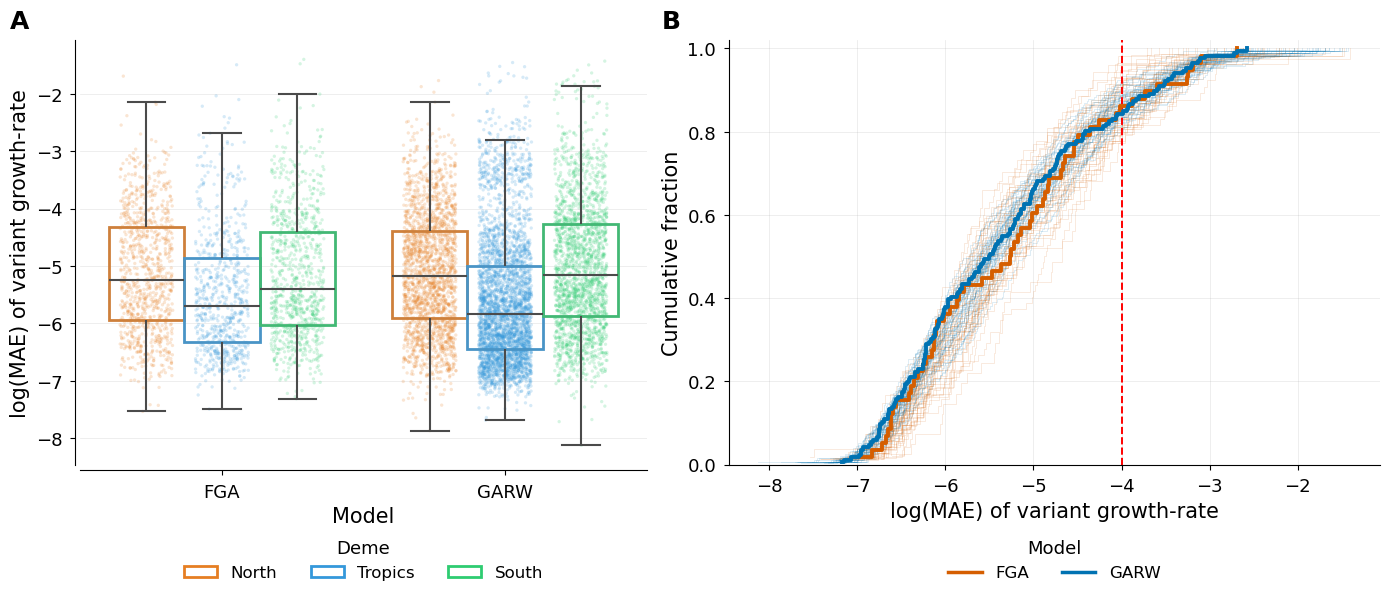

saved figureS5_growth_rate_candidates_boxplot.{pdf,png}  [pooling n=45 candidate runs]
-> /Users/zo/projects/research/antigen-tex/reviews/round1/figures


In [4]:
# ======================================================================
# Variant-level growth-rate benchmark (flu-like candidates). Two panels:
#
#   (A) Distribution of the per-variant growth-rate error, log(MAE), by model
#       (FGA, GARW) and deme (north, tropics, south), over every converged
#       variant-window with >= MIN_POINTS points, pooled across all candidate
#       simulations (figure 5's per-variant boxplot, pooled). Boxes span the IQR
#       with the median; the point cloud shows individual windows so the tail is
#       visible.
#   (B) Empirical CDF of the same per-variant log(MAE). Each faint line is one
#       candidate run, colored by model (FGA vs GARW), so the spread across
#       simulations shows as a background band; the two bold lines are the
#       representative run -- the run that will carry the main-text detailed
#       analysis (a random placeholder until chosen; see REPRESENTATIVE_RUN). The
#       red dashed line is the log(MAE) threshold (ZOOM_LOGMAE_THRESHOLD) above
#       which windows are treated as zoom-in-worthy; where each curve crosses it
#       gives how often such elevated-error windows occur.
#       (Per-model n's, converged: FGA 2,578, GARW 7,999 -- see the caveat below.)
#
#   Together: the models recover variant growth rates well and consistently across
#   simulations (A; the representative run sits within the ensemble band in B), and
#   only a thin tail (B, right of the red line) reaches zoom-in-worthy error. NOTE:
#   FGA and GARW look comparable here, but on converged windows only -- see the
#   survivorship caveat in the load cell (issue #29).
# ======================================================================


def growth_panel(ax):
    # Every variant-window as a low-alpha, dodged point cloud so the extreme
    # outliers (the zoom-in targets) stay individually visible. Rasterized so
    # ~8k points do not bloat the vector PDF, while boxes/text stay vector.
    sns.stripplot(
        data=variants, x='model', y='log_mae', order=MODEL_ORDER,
        hue='location', hue_order=DEME_ORDER, palette=deme_palette,
        dodge=True, jitter=0.28, size=2.4, alpha=0.20, linewidth=0,
        legend=False, ax=ax, zorder=1,
    )
    for coll in ax.collections:
        coll.set_rasterized(True)
    # Outlined boxes on top (transparent face so the cloud shows through), as in
    # figure 5. showfliers=False since the stripplot already shows every point.
    bp = sns.boxplot(
        data=variants, x='model', y='log_mae', order=MODEL_ORDER,
        hue='location', hue_order=DEME_ORDER, palette=deme_palette,
        showfliers=False, linewidth=1.5, ax=ax, zorder=2,
    )
    for patch in bp.patches:
        edge = patch.get_facecolor()
        patch.set_facecolor('none')
        patch.set_edgecolor(edge)
        patch.set_linewidth(2)
    plt.setp(bp.lines, linewidth=1.5)
    ax.set_xlabel('Model')
    ax.set_ylabel('log(MAE) of variant growth-rate')
    if ax.legend_ is not None:
        ax.legend_.remove()
    handles = [Patch(facecolor='none', edgecolor=deme_palette[d], linewidth=2,
                     label=d.capitalize()) for d in DEME_ORDER]
    ax.legend(handles=handles, title='Deme', ncol=3, loc='upper center',
              bbox_to_anchor=(0.5, -0.14), frameon=False)
    ax.grid(True, axis='y', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, offset=4)


def ecdf_panel(ax):
    def _ecdf(vals):
        x = np.sort(np.asarray(vals))
        return (x, np.arange(1, len(x) + 1) / len(x)) if len(x) else None

    # One faint ECDF per candidate run x model, so the spread across simulations
    # reads as a background band. Rasterized to keep the vector PDF light.
    for (cfg, run), g in variants.groupby(['config', 'run']):
        if (cfg, int(run)) == representative_run:
            continue
        for model in MODEL_ORDER:
            e = _ecdf(g.loc[g['model'] == model, 'log_mae'])
            if e is None:
                continue
            line = ax.step(e[0], e[1], where='post', color=MODEL_COLORS[model],
                           lw=0.6, alpha=0.15, zorder=1)[0]
            line.set_rasterized(True)

    # Representative run bold on top (detail goes in the caption, not the legend).
    rep = variants[(variants['config'] == representative_run[0])
                   & (variants['run'].astype(int) == representative_run[1])]
    for model in MODEL_ORDER:
        e = _ecdf(rep.loc[rep['model'] == model, 'log_mae'])
        if e is not None:
            ax.step(e[0], e[1], where='post', color=MODEL_COLORS[model],
                    lw=2.8, zorder=3)

    # Red dashed log(MAE) threshold for zoom-in-worthy windows (tweak via
    # ZOOM_LOGMAE_THRESHOLD); where each curve crosses it = how often they occur.
    ax.axvline(ZOOM_LOGMAE_THRESHOLD, color='red', ls='--', lw=1.4, zorder=2)

    ax.set_xlabel('log(MAE) of variant growth-rate')
    ax.set_ylabel('Cumulative fraction')
    ax.set_ylim(0, 1.02)
    # Legend: models only (n's and the representative-run detail live in the caption).
    handles = [Line2D([], [], color=MODEL_COLORS[m], lw=2.5, label=m)
               for m in MODEL_ORDER]
    ax.legend(handles=handles, title='Model', ncol=2, loc='upper center',
              bbox_to_anchor=(0.5, -0.14), frameon=False)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)


def build_figure():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8),
                             gridspec_kw={'width_ratios': [1, 1.15]})
    growth_panel(axes[0])
    ecdf_panel(axes[1])
    fig.tight_layout()
    add_panel_letters(fig, axes, 'AB')
    return fig


FIG_DIR.mkdir(parents=True, exist_ok=True)
# NOTE: the stem keeps the '_boxplot' suffix for filename stability; the figure now
# has a boxplot (A) and an ECDF (B). Rename during the supplement renumbering pass.
stem = 'figureS5_growth_rate_candidates_boxplot'
fig = build_figure()
for ext in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'{stem}.{ext}', dpi=300, bbox_inches='tight')
plt.show()
print(f'saved {stem}.{{pdf,png}}  [pooling n={n_present} candidate runs]')
print('->', FIG_DIR.resolve())

In [5]:
# --- zoom-in candidates: save top-N to a file for a future zoom-in notebook ---
# Each row locates a variant-window that a fig-6-style notebook can re-plot: form
# build = f'{batch}/{config}__run_{run}' and call
# get_filtered_growth_rates_df(build, model, location, pivot_date, ...). The
# 'variant' column flags which variant drove the error. Change N_ZOOM above to
# save more/fewer targets.
ZOOM_PATH = Path('..') / 'results' / 'aggregated' / BATCH / 'growth_rate_zoom_in_candidates.csv'

zoom_cols = ['config', 'run', 'pivot_date', 'model', 'location', 'variant',
             'mae', 'mse', 'normalized_mae', 'r2', 'n_points']
zoom = variants.sort_values('mae', ascending=False).head(N_ZOOM)[zoom_cols].reset_index(drop=True)
zoom.insert(0, 'batch', BATCH)
zoom.insert(1, 'build', BATCH + '/' + zoom['config'] + '__run_' + zoom['run'].astype(str))

ZOOM_PATH.parent.mkdir(parents=True, exist_ok=True)
zoom.to_csv(ZOOM_PATH, index=False)
print(f'wrote top {N_ZOOM} zoom-in candidates -> {ZOOM_PATH}')
print(zoom[['build', 'pivot_date', 'model', 'location', 'variant', 'mae', 'r2']].to_string(index=False))

wrote top 20 zoom-in candidates -> ../results/aggregated/2026-07-04-reviewer-runs/growth_rate_zoom_in_candidates.csv
                                                                            build pivot_date model location  variant      mae            r2
 2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.2_epitopeAcceptance_0.75__run_28 2030-10-01   FGA    south      4.0 0.245753    -98.329303
 2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75__run_1 2052-10-01  GARW    south     26.0 0.238520  -3697.044066
2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75__run_22 2052-10-01  GARW  tropics     28.0 0.232616 -45944.992754
 2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.2_epitopeAcceptance_0.75__run_19 2052-10-01   FGA    south     27.0 0.227651  -1113.396620
 2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.2_epitopeAcceptance_0.75__run_23 2044-04-01   FGA  tropics     19.0 0.223817  -2492.253859
 2026-07-04-reviewer-runs/nonEpitopeAccepta